In [13]:
# IMPORTAÇÃO DAS BIBLIOTECAS NECESSÁRIAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn - Pré-processamento e Modelagem
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Configuração de estilo visual dos gráficos
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [15]:
# CARGA A INSPEÇÃO INICIAL DOS DADOS

# Carregando o arquivo CSV disponibilizado
df = pd.read_csv('/content/dataset_inadimplencia_clinica.csv')

# Exibindo as primeiras linhas do dataset
print("--- Primeiras 5 linhas do dataset ---")
print(df.head())

# Informações sobre colunas e tipos de dados
print("\n--- Informações Estruturais do Dataset ---")
df.info()

# Verificando a distribuição da variável alvo
print("\n--- Distribuição da Variável Alvo (risco_inadimplencia) ---")
print(df['risco_inadimplencia'].value_counts())

--- Primeiras 5 linhas do dataset ---
   id_paciente  idade genero      tipo_plano  tempo_cliente_meses  \
0            1     56      F  Bradesco Saúde                    9   
1            2     69      M      Particular                   53   
2            3     46  Outro          Unimed                   74   
3            4     32      F  Bradesco Saúde                   44   
4            5     60      M          Unimed                   66   

   total_consultas  consultas_canceladas  valor_medio_consulta  \
0               19                     4                267.30   
1               28                     0                405.19   
2               23                     4                304.19   
3               30                     4                298.17   
4                4                     2                131.28   

   total_pagamentos  pagamentos_em_dia  ...  atraso_medio_dias  \
0                 4                  3  ...               15.4   
1                2

In [16]:
# TRATAMENTO E TRANSFORMACÃO DOS DADOS

# Verificar se existem valores nulos no dataset
print("Valores ausentes por coluna:")
print(df.isnull().sum())

# Tratamento de nulos
df = df.dropna()

# Tratamento e verificação de inconsistências numéricas
print("\nEstatísticas Descritivas do Dataset:")
print(df.describe())

# Salvando o dataset limpo e tratado em CSV
df.to_csv('dados_limpos.csv', index=False)
print("\nDataset limpo exportado com sucesso como 'dados_limpos.csv'!")

Valores ausentes por coluna:
id_paciente                   0
idade                         0
genero                        0
tipo_plano                    0
tempo_cliente_meses           0
total_consultas               0
consultas_canceladas          0
valor_medio_consulta          0
total_pagamentos              0
pagamentos_em_dia             0
numero_atrasos                0
atraso_medio_dias             0
maior_atraso_dias             0
percentual_atrasos            0
valor_total_devido            0
desconto_medio                0
principal_metodo_pagamento    0
pagamentos_pendentes          0
pagamentos_inadimplentes      0
status_pagamento              0
risco_inadimplencia           0
dtype: int64

Estatísticas Descritivas do Dataset:
       id_paciente       idade  tempo_cliente_meses  total_consultas  \
count   300.000000  300.000000           300.000000       300.000000   
mean    150.500000   50.533333            48.823333        22.386667   
std      86.746758   18.916881  

In [17]:
# ANÁLISE ESTATÍSTICA COM NUMPY

# Extraindo o array de tempo de atraso médio em dias
atraso_dias = df['atraso_medio_dias'].to_numpy()

# Cálculo da média e desvio padrão usando NumPy
media_atraso = np.mean(atraso_dias)
desvio_atraso = np.std(atraso_dias)
mediana_atraso = np.median(atraso_dias)
max_atraso = np.max(atraso_dias)

print("="*50)
print("   ESTATÍSTICAS DO TEMPO DE ATRASO (NumPy)   ")
print("="*50)
print(f"• Média do Tempo de Atraso:    {media_atraso:.2f} dias")
print(f"• Desvio Padrão do Atraso:     {desvio_atraso:.2f} dias")
print(f"• Mediana do Atraso:          {mediana_atraso:.2f} dias")
print(f"• Maior Atraso Registrado:     {max_atraso:.2f} dias")
print("="*50)

   ESTATÍSTICAS DO TEMPO DE ATRASO (NumPy)   
• Média do Tempo de Atraso:    12.43 dias
• Desvio Padrão do Atraso:     7.85 dias
• Mediana do Atraso:          12.10 dias
• Maior Atraso Registrado:     36.00 dias


/tmp/ipykernel_1776/1383792850.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


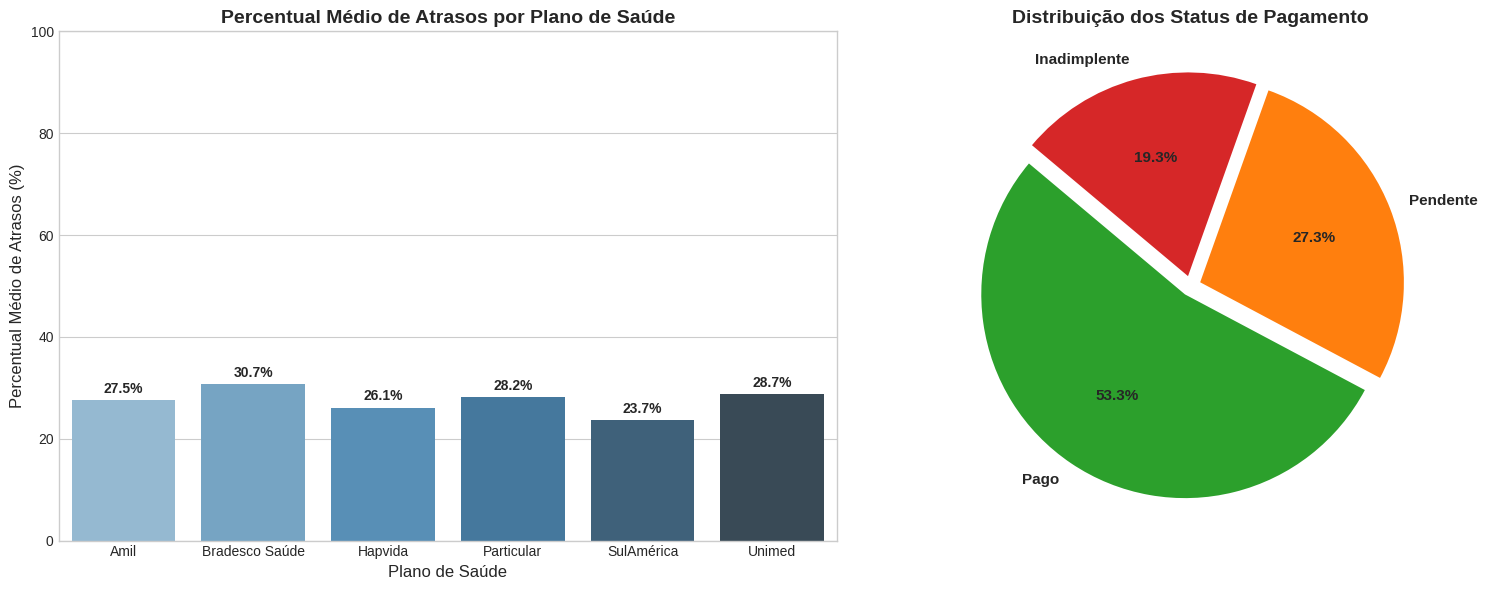

In [18]:
# VISUALIZAÇÕES DE DADOS (MATPLOTLIB)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico de Barras Referente Percentual Médio de Atraso por Plano de Saúde ---
atraso_por_plano = df.groupby('tipo_plano')['percentual_atrasos'].mean().reset_index()

sns.barplot(
    data=atraso_por_plano,
    x='tipo_plano',
    y='percentual_atrasos',
    ax=axes[0],
    palette='Blues_d'
)
axes[0].set_title('Percentual Médio de Atrasos por Plano de Saúde', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Plano de Saúde', fontsize=12)
axes[0].set_ylabel('Percentual Médio de Atrasos (%)', fontsize=12)
axes[0].set_ylim(0, 100)

for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

# --- Gráfico de Pizza Referente a Distribuição do Status de Pagamento ---
status_counts = df['status_pagamento'].value_counts()
colors = ['#2ca02c', '#ff7f0e', '#d62728']

axes[1].pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=(0.05, 0.05, 0.05),
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)
axes[1].set_title('Distribuição dos Status de Pagamento', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [23]:
# SEPARAÇÃO DAS FEATURES E TARGET

# Definindo atributos preditores (X) e a variavel de resposta (y)
X = df.drop(columns=['id_paciente', 'risco_inadimplencia'])
y = df['risco_inadimplencia']

# Mapeando variaveis numericas e categoricas
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Atributos Numéricos ({len(num_cols)}): {num_cols}")
print(f"Atributos Categóricos ({len(cat_cols)}): {cat_cols}")

# Divisão do dataset em Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nTamanho dos dados de Treino: {X_train.shape[0]} amostras")
print(f"Tamanho dos dados de Teste: {X_test.shape[0]} amostras")

Atributos Numéricos (15): ['idade', 'tempo_cliente_meses', 'total_consultas', 'consultas_canceladas', 'valor_medio_consulta', 'total_pagamentos', 'pagamentos_em_dia', 'numero_atrasos', 'atraso_medio_dias', 'maior_atraso_dias', 'percentual_atrasos', 'valor_total_devido', 'desconto_medio', 'pagamentos_pendentes', 'pagamentos_inadimplentes']
Atributos Categóricos (4): ['genero', 'tipo_plano', 'principal_metodo_pagamento', 'status_pagamento']

Tamanho dos dados de Treino: 240 amostras
Tamanho dos dados de Teste: 60 amostras


In [24]:
# CONSTRUÇÃO DO PIPELINE E TREINAMENTO ML

# Pré-processamento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# Pipeline de Classificação com Random Forest
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Treinamento do Modelo
model_pipeline.fit(X_train, y_train)
print("Modelo de Machine Learning treinado com sucesso!")

Modelo de Machine Learning treinado com sucesso!


Acurácia Geral do Modelo: 98.33%

--- Relatório de Classificação ---
              precision    recall  f1-score   support

        Alto       0.97      1.00      0.98        31
       Baixo       1.00      1.00      1.00         6
       Medio       1.00      0.96      0.98        23

    accuracy                           0.98        60
   macro avg       0.99      0.99      0.99        60
weighted avg       0.98      0.98      0.98        60



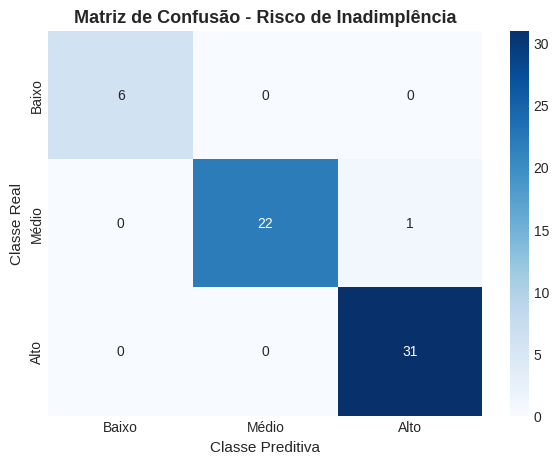

In [25]:
# AVALIAÇÃO DO MODELO DE ML

# Predições no conjunto de teste
y_pred = model_pipeline.predict(X_test)

# Cálculo da Acurácia
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia Geral do Modelo: {accuracy * 100:.2f}%\n")

# Relatório de Classificação Detalhado
print("--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred))

# Matriz de Confusão
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred, labels=['Baixo', 'Medio', 'Alto'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Baixo', 'Médio', 'Alto'],
            yticklabels=['Baixo', 'Médio', 'Alto'])
plt.title('Matriz de Confusão - Risco de Inadimplência', fontsize=13, fontweight='bold')
plt.xlabel('Classe Preditiva', fontsize=11)
plt.ylabel('Classe Real', fontsize=11)
plt.show()

/tmp/ipykernel_1776/3580828445.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importance, x='Importancia', y='Atributo', palette='viridis')


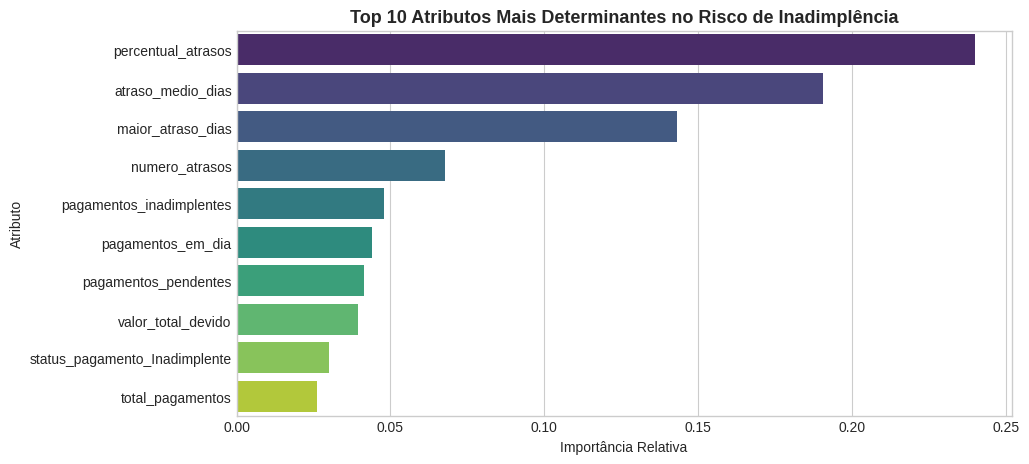

In [22]:
# IMPORTÂNCIA DAS FEATURES (INSIGHTS)

# Obter nomes das features após OneHotEncoding
ohe_cols = list(model_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_cols))
feature_names = num_cols + ohe_cols

# Importâncias
importances = model_pipeline.named_steps['classifier'].feature_importances_
df_importance = pd.DataFrame({'Atributo': feature_names, 'Importancia': importances})
df_importance = df_importance.sort_values(by='Importancia', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_importance, x='Importancia', y='Atributo', palette='viridis')
plt.title('Top 10 Atributos Mais Determinantes no Risco de Inadimplência', fontsize=13, fontweight='bold')
plt.xlabel('Importância Relativa')
plt.ylabel('Atributo')
plt.show()